In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn. metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [105]:
df = pd.read_csv('Housing.csv')
df.head(2)

,rownames,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,1,42000,5850,3,1,2,yes,no,yes,no,no,1,no
1,2,38500,4000,2,1,1,yes,no,no,no,no,0,no


In [19]:
df.shape

(546, 13)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546 entries, 0 to 545
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   rownames  546 non-null    int64 
 1   price     546 non-null    int64 
 2   lotsize   546 non-null    int64 
 3   bedrooms  546 non-null    int64 
 4   bathrms   546 non-null    int64 
 5   stories   546 non-null    int64 
 6   driveway  546 non-null    object
 7   recroom   546 non-null    object
 8   fullbase  546 non-null    object
 9   gashw     546 non-null    object
 10  airco     546 non-null    object
 11  garagepl  546 non-null    int64 
 12  prefarea  546 non-null    object
dtypes: int64(7), object(6)
memory usage: 55.6+ KB


In [21]:
df.drop(['rownames'], axis=1, inplace=True)

In [22]:
df.head(1)

,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,42000,5850,3,1,2,yes,no,yes,no,no,1,no


In [23]:
yes_no_cols = ['driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'prefarea']

In [24]:
df[yes_no_cols] = df[yes_no_cols].replace({'yes': 1, 'no': 0})

In [26]:
df.head(2)

,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,42000,5850,3,1,2,1,0,1,0,0,1,0
1,38500,4000,2,1,1,1,0,0,0,0,0,0


In [29]:
df.describe()

,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
count,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000
mean,68121.597070,5150.265568,2.965201,1.285714,1.807692,0.858974,0.177656,0.349817,0.045788,0.316850,0.692308,0.234432
std,26702.670926,2168.158725,0.737388,0.502158,0.868203,0.348367,0.382573,0.477349,0.209216,0.465675,0.861307,0.424032
min,25000.000000,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,49125.000000,3600.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,62000.000000,4600.000000,3.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,82000.000000,6360.000000,3.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000
max,190000.000000,16200.000000,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000


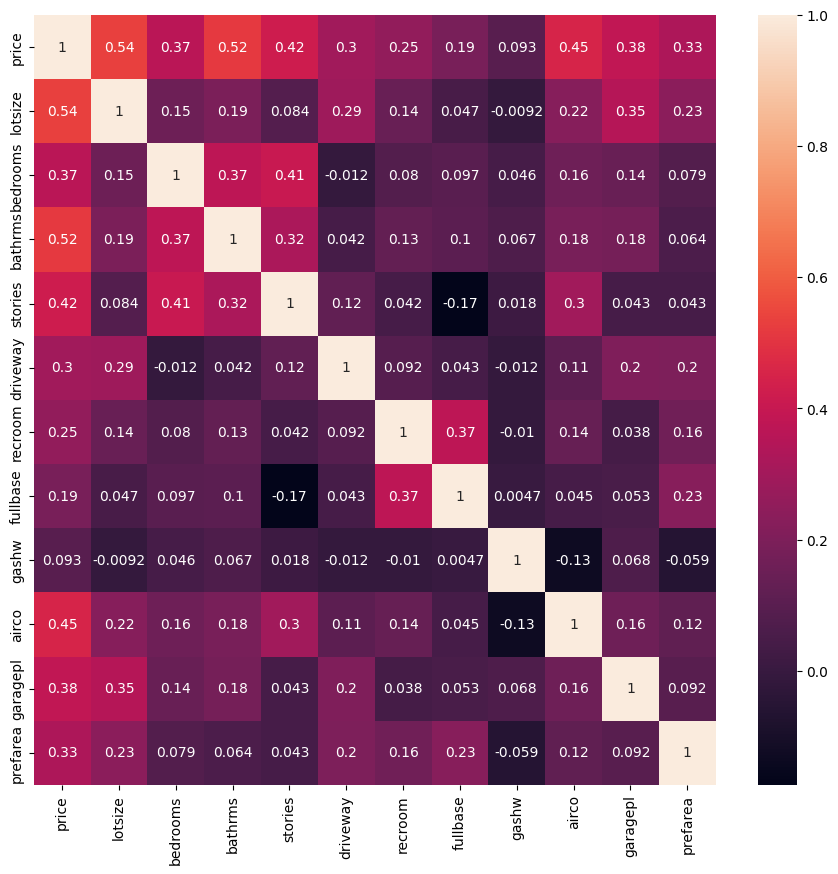

In [36]:
plt.figure(figsize=(11,10))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [41]:
x = df.iloc[:,1:12]
y = df.iloc[:,:1]

### Train Test Split

In [45]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.1, random_state=40)

In [50]:
lr = LinearRegression()
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [54]:
x_test.head()

,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
42,4640,4,1,2,1,0,0,0,0,1,0
62,4280,2,1,1,1,0,0,0,1,2,0
0,5850,3,1,2,1,0,1,0,0,1,0
423,2880,3,1,2,1,0,0,0,0,0,1
112,5000,3,1,2,1,0,0,0,1,0,0


In [56]:
y_test.head()

,price
42,82000
62,52000
0,42000
423,62900
112,92000


In [51]:
y_pred = lr.predict(x_test)

### Evaluation Matrics

In [62]:
r2 = r2_score(y_test, y_pred)
r2

0.6308457955698132

In [63]:
mae = mean_absolute_error(y_test, y_pred)
mae

10603.284111378314

In [88]:
mse = mean_squared_error(y_test, y_pred)
mse

209420355.22037822

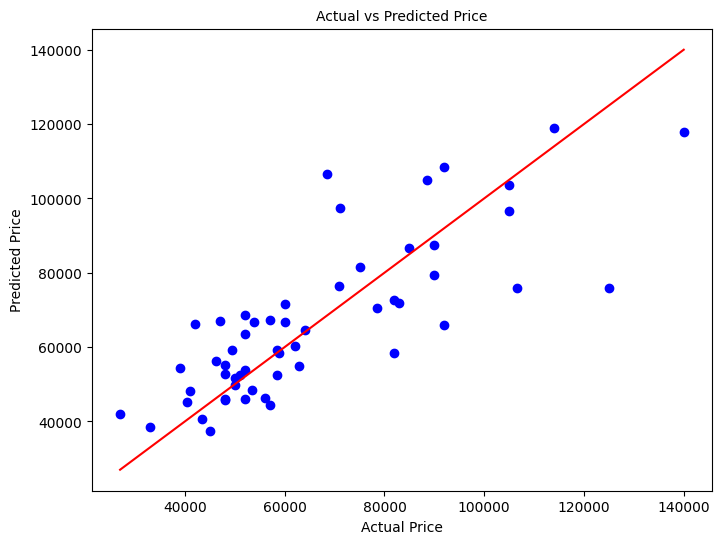

In [103]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='b' )
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color='r')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price", fontsize=10)
plt.show()

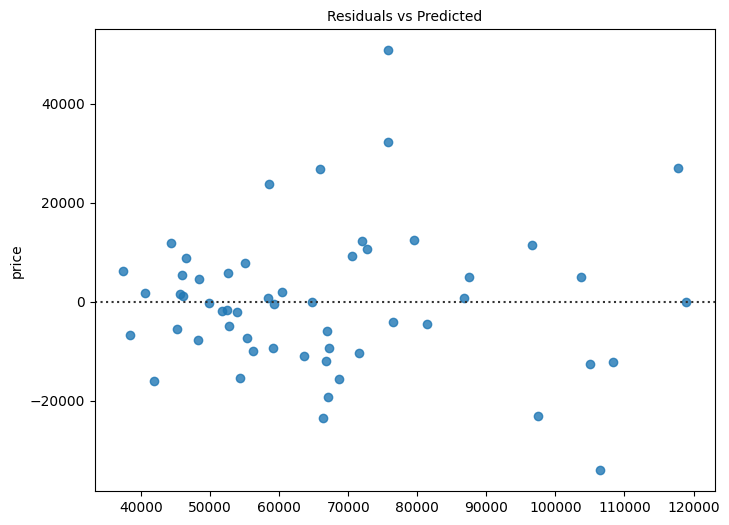

In [104]:
plt.figure(figsize=(8,6))
sns.residplot(x=y_pred, y=y_test)
plt.title('Residuals vs Predicted', fontsize=10)
plt.show()